---

# Mapa de Quantidade de Dias com Temperatura Máxima no Mês de Agosto de 2024 Acima do Percentil de 90% com Dados do CPC

---

- `OBJETIVO`:
> Este código calcula e plota a quantidade de dias do mês de agosto de 2024 que tiveram temperatura máxima diária acima do percentil de 90% (P90) em relação a todos os meses de agosto entre 1980 e 2023 dos dados do CPC.

- `DADOS DE ENTRADA`:
> Dados globais diários de temperatura máxima do Climate Prediction Center (CPC) com 50km de resolução espacial. Os dados são disponíveis desde 1979 e são carregados diretamente através do Xarray via Protocolo OPeNDAP para [Tmax](http://apdrc.soest.hawaii.edu:80/dods/public_data/CPC_Temperature/tmax). Mais informações sobre os dados de temperatura do CPC acesse [aqui](http://apdrc.soest.hawaii.edu/datadoc/cpc_temperature.php) e diversos outros dados disponibilizados pelo Asia-Pacific Data Research Center, acesse [aqui](https://apdrc.soest.hawaii.edu/data/data.php?discipline_index=3).

- `DADOS DE SAÍDA`:
> 1. Mapa em formato JPG da quantidade de dias acima do P90 para agosto de 2024 para o Brasil. Exemplo: `Fig_4_diasacimaP90_brasil_agosto2024.jpg.jpg`

- `OBSERVAÇÕES`:
   > Nenhuma.

- `REALIZADO POR`:
> Prof. Enrique V. Mattos / UNIFEI - 29/05/2026

- `ATUALIZADO POR`:
> Prof. Enrique V. Mattos / UNIFEI - 29/05/2026
---

# Prepando ambiente


In [1]:
#=========================================================================================================================#
#                                          INSTALAÇÃO E IMPORTAÇÃO DAS BIBLIOTECAS
#=========================================================================================================================#
# instala bibliotecas
!pip install -q xarray dask netCDF4 bottleneck xclim ultraplot cartopy salem rasterio pyproj geopandas

# importa bibliotecas
import xarray as xr
import xclim as xc
import ultraplot as uplt
import salem
import os
import cartopy.io.shapereader as shpreader
import cartopy.crs as ccrs
import numpy as np
from dask.diagnostics import ProgressBar
from cartopy.mpl.patch import geos_to_path
from matplotlib.path import Path
from matplotlib.patches import PathPatch
import warnings
warnings.filterwarnings("ignore")

#=========================================================================================================================#
#                                  MONTA O GOOGLE DRIVE E CRIA O DIRETÓRIO DE SAÍDA
#=========================================================================================================================#
# monta o drive
from google.colab import drive
drive.mount('/content/drive')

# diretório raiz
dir = '/content/drive/MyDrive/PYHTON/00_GITHUB/000_CODIGOS_REFERENCIA/09_INDICES_CLIMATICOS_XCLIM'

# diretório de saída
dir_output = f'{dir}/output'

# cria pasta de saída
os.makedirs(dir_output, exist_ok=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 384.7/384.7 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.2/194.2 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.4/79.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.5/83.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 61.8 MB/s eta 0:00:00


Mounted at /content/drive


# Calcula Quantidade de Dias de Agosto/2024 com Temperatura Máxima > P90 (1980-2023)

In [11]:
#=========================================================================================================================#
#                                                DEFINE O MÊS E ANO
#=========================================================================================================================#
mes_num, mes_nome, dia_final_mes = '08', 'agosto', '31'

#=========================================================================================================================#
#                                                CARREGA OS DADOS DO CPC
#=========================================================================================================================#
print("[1/7] Carregando dados do CPC...")

# limites
#lonmin, lonmax, latmin, latmax = -53.3, -43.9, -25.4, -19.7 # estado de SP
lonmin, lonmax, latmin, latmax = -75.0, -33.0, -35.0, 7.0 # Brasil

# leitura do shapefile que contêm o contorno do Brasil
shapefile_brasil = salem.read_shapefile('https://github.com/evmpython/Minicurso_UFMS_SEMADESC_marco_2026/raw/main/01_utils/BRAZIL.shp')

# carrega com chunking para processamento lazy
cpc_tmax_diaria = xr.open_dataset('http://apdrc.soest.hawaii.edu:80/dods/public_data/CPC_Temperature/tmax', chunks={'time': 100, 'lat': 50, 'lon': 50}).squeeze()

# transforma longitudes
cpc_tmax_diaria.coords['lon'] = ((cpc_tmax_diaria.coords['lon'] + 180) % 360) - 180 ; cpc_tmax_diaria = cpc_tmax_diaria.sortby(cpc_tmax_diaria.lon)

# recorta para o Brasil
cpc_tmax_diaria = cpc_tmax_diaria.sel(lon=slice(lonmin, lonmax), lat=slice(latmin, latmax))

# atribui unidade
cpc_tmax_diaria['tmax'].attrs['units'] = 'C'

#=========================================================================================================================#
#                                                 CÁLCULO DO P90
#=========================================================================================================================#
# ano INICIAL e FINAL
hist_start_year, hist_end_year = 1980, 2023

print(f"[2/7]: Calculando P90 para {mes_nome} {hist_start_year}-{hist_end_year}...")

# calcula o percentil mensal diretamente
with ProgressBar():

    # extrai apenas os dados necessários (agostos/setembros)
    aug_months = []
    for year in range(hist_start_year, hist_end_year + 1):
        print(f"  Processando {mes_nome} de {year}...")

        # Modified to select all days of the month, not just the first day
        aug_data = cpc_tmax_diaria['tmax'].sel(time=slice(f'{year}-{mes_num}-01', f'{year}-{mes_num}-{dia_final_mes}'))
        aug_months.append(aug_data)

    # empilha todos os agostos/setembros
    cpc_tmax_aug_hist = xr.concat(aug_months, dim='time')

    # calcula percentil
    tmax_p90 = cpc_tmax_aug_hist.quantile(0.90, dim='time', keep_attrs=True).compute()
    tmax_p90.attrs['units'] = 'C'

print("[3/7]: P90 calculado!")

#=========================================================================================================================#
#                                CALCULA A QUANTIDADE DE DIAS ACIMA DO P90 EM AGOSTO/2024
#=========================================================================================================================#
print("[4/7]: Processando agosto de 2024...")

# carrega apenas agosto de 2024
tmax_aug_2024 = cpc_tmax_diaria['tmax'].sel(time=slice('2024-08-01', '2024-08-31')).compute()
tmax_aug_2024.attrs['units'] = 'C'

print("[5/7]: Calculando dias acima do P90...")

# contagem de dias
dias_acima_p90 = (tmax_aug_2024 > tmax_p90).sum(dim='time').astype(int)
dias_acima_p90.name = 'dias_acima_p90_agosto_2024'

print("[6/7]: Aplicando máscara do Brasil...")
#dias_acima_p90 = dias_acima_p90.salem.roi(shape=shapefile_brasil).compute()

#=========================================================================================================================#
#                                            SALVA RESULTADO ARQUIVO NETCDF
#=========================================================================================================================#

print("[7/7]: Salvando arquivo...")
output_filename = f"{dir_output}/dias_acima_p90_agosto_2024.nc"
dias_acima_p90.to_netcdf(output_filename)

print(f"\n✅ Arquivo salvo: {output_filename}")
print(f"📊 Total de dias (média espacial): {dias_acima_p90.mean().values:.1f} dias")
print(f"📍 Máximo local: {dias_acima_p90.max().values} dias")
print(f"📍 Mínimo local: {dias_acima_p90.min().values} dias")

[1/7] Carregando dados do CPC...
[2/7]: Calculando P90 para agosto 1980-2023...
  Processando agosto de 1980...
  Processando agosto de 1981...
  Processando agosto de 1982...
  Processando agosto de 1983...
  Processando agosto de 1984...
  Processando agosto de 1985...
  Processando agosto de 1986...
  Processando agosto de 1987...
  Processando agosto de 1988...
  Processando agosto de 1989...
  Processando agosto de 1990...
  Processando agosto de 1991...
  Processando agosto de 1992...
  Processando agosto de 1993...
  Processando agosto de 1994...
  Processando agosto de 1995...
  Processando agosto de 1996...
  Processando agosto de 1997...
  Processando agosto de 1998...
  Processando agosto de 1999...
  Processando agosto de 2000...
  Processando agosto de 2001...
  Processando agosto de 2002...
  Processando agosto de 2003...
  Processando agosto de 2004...
  Processando agosto de 2005...
  Processando agosto de 2006...
  Processando agosto de 2007...
  Processando agosto de 

In [12]:
# mostra os dados da TMAX do CPC que foram carregados
cpc_tmax_diaria

<xarray.Dataset> Size: 489MB
Dimensions:  (time: 17321, lat: 84, lon: 84)
Coordinates:
  * time     (time) datetime64[ns] 139kB 1979-01-01 1979-01-02 ... 2026-06-03
  * lat      (lat) float64 672B -34.75 -34.25 -33.75 -33.25 ... 5.75 6.25 6.75
  * lon      (lon) float64 672B -74.75 -74.25 -73.75 ... -34.25 -33.75 -33.25
Data variables:
    tmax     (time, lat, lon) float32 489MB dask.array<chunksize=(100, 40, 30), meta=np.ndarray>
Attributes:
    title:          CPC Global Daily Maximum Temperature
    Conventions:    COARDS\nGrADS
    dataType:       Grid
    documentation:  http://apdrc.soest.hawaii.edu/datadoc/cpc_temperature.php
    history:        Fri Jun 05 01:30:56 HST 2026 : imported by GrADS Data Ser...

In [13]:
# dados de TMAX de todos agostos desde 1980
cpc_tmax_aug_hist

<xarray.DataArray 'tmax' (time: 1364, lat: 84, lon: 84)> Size: 38MB
dask.array<concatenate, shape=(1364, 84, 84), dtype=float32, chunksize=(31, 44, 48), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 11kB 1980-08-01 1980-08-02 ... 2023-08-31
  * lat      (lat) float64 672B -34.75 -34.25 -33.75 -33.25 ... 5.75 6.25 6.75
  * lon      (lon) float64 672B -74.75 -74.25 -73.75 ... -34.25 -33.75 -33.25
Attributes:
    long_name:  daily maximum temperature [deg c] 
    units:      C

In [14]:
# dados de TMAX do P90
tmax_p90

<xarray.DataArray 'tmax' (lat: 84, lon: 84)> Size: 28kB
array([[      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       ...,
       [35.412273, 31.870466, 21.639013, ...,       nan,       nan,
              nan],
       [33.91299 , 34.519726, 29.247393, ...,       nan,       nan,
              nan],
       [31.671118, 34.561234, 33.992428, ...,       nan,       nan,
              nan]], dtype=float32)
Coordinates:
  * lat       (lat) float64 672B -34.75 -34.25 -33.75 -33.25 ... 5.75 6.25 6.75
  * lon       (lon) float64 672B -74.75 -74.25 -73.75 ... -34.25 -33.75 -33.25
    quantile  float64 8B 0.9
Attributes:
    long_name:  daily maximum temperature [deg c] 
    units:      C

In [15]:
# dados de TMAX de agosto de 2024
tmax_aug_2024

<xarray.DataArray 'tmax' (time: 31, lat: 84, lon: 84)> Size: 875kB
array([[[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        ...,
        [34.040287, 30.64321 , 20.16598 , ...,       nan,       nan,
               nan],
        [32.502712, 32.975845, 27.257122, ...,       nan,       nan,
               nan],
        [30.24853 , 32.36534 , 31.23353 , ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
...
        [35.84004 , 32.48605 , 22.325506, ...,       nan,       nan,
               nan],
        [33.729477, 34.609737, 29.440235, ...,       nan,       nan,
               nan],
        [31.179787, 33.995937, 33.435486, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        ...,
        [35.72949 , 32.49046 , 22.251263, ...,       nan,       nan,
               nan],
        [33.974773, 34.915485, 29.472286, ...,       nan,       nan,
               nan],
        [31.642818, 34.57265 , 33.42875 , ...,       nan,       nan,
               nan]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 248B 2024-08-01 2024-08-02 ... 2024-08-31
  * lat      (lat) float64 672B -34.75 -34.25 -33.75 -33.25 ... 5.75 6.25 6.75
  * lon      (lon) float64 672B -74.75 -74.25 -73.75 ... -34.25 -33.75 -33.25
Attributes:
    long_name:  daily maximum temperature [deg c] 
    units:      C

In [16]:
# Dataset com a quantidade de dias de agosto/2024 > 35C
dias_acima_p90

<xarray.DataArray 'dias_acima_p90_agosto_2024' (lat: 84, lon: 84)> Size: 56kB
array([[ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       ...,
       [ 9, 12, 12, ...,  0,  0,  0],
       [ 7, 13, 12, ...,  0,  0,  0],
       [ 8,  8,  6, ...,  0,  0,  0]])
Coordinates:
  * lat       (lat) float64 672B -34.75 -34.25 -33.75 -33.25 ... 5.75 6.25 6.75
  * lon       (lon) float64 672B -74.75 -74.25 -73.75 ... -34.25 -33.75 -33.25
    quantile  float64 8B 0.9
Attributes:
    long_name:  daily maximum temperature [deg c] 
    units:      C

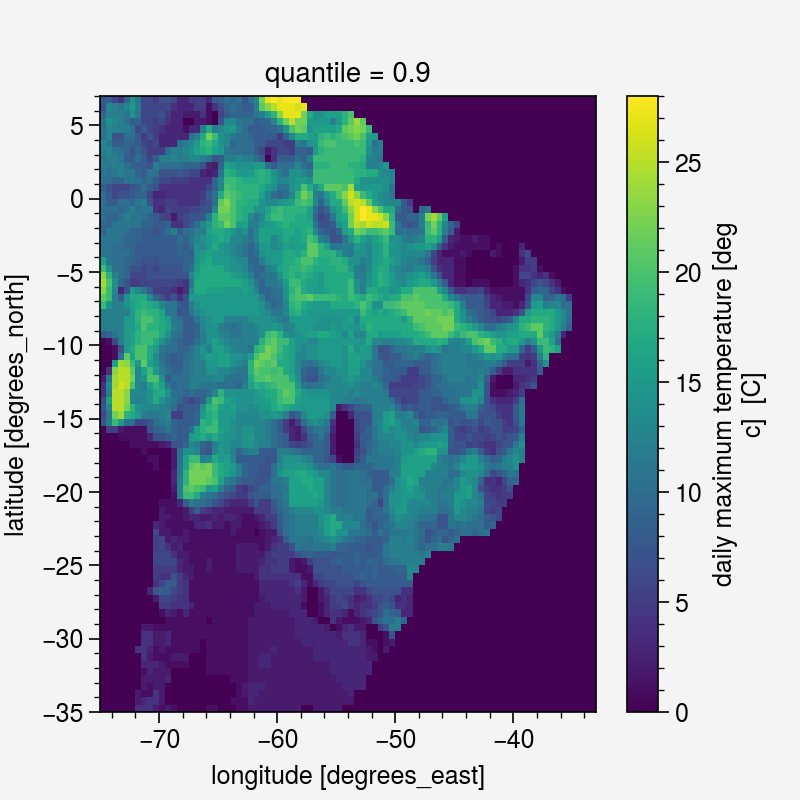

In [17]:
# mapa simples
dias_acima_p90.plot()

# Plota Figura

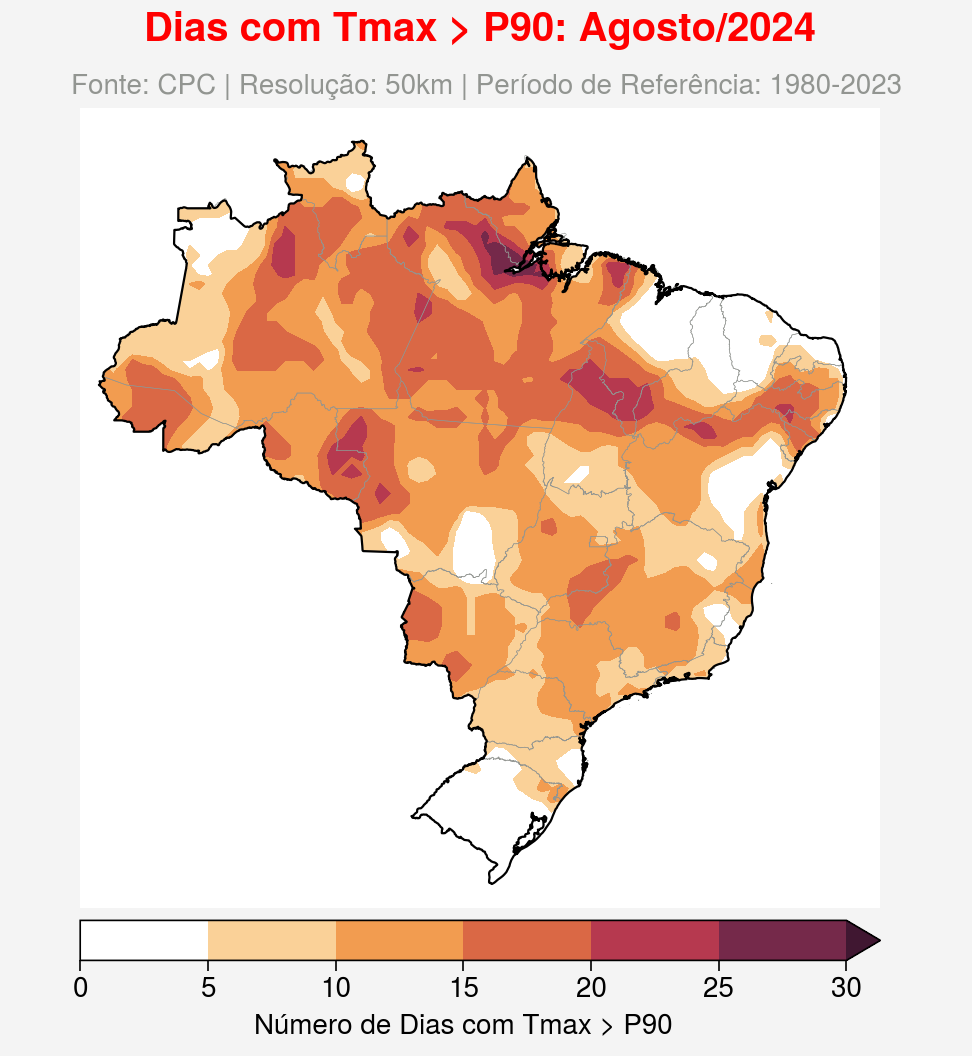

In [20]:
#=========================================================================================================================#
#                                                  PLOTA MAPA
#=========================================================================================================================#
#------------------------------------------------------------------#
#                    FORMATAÇÃO DA FIGURA
#------------------------------------------------------------------#
# cria a moldura da figura
fig, ax = uplt.subplots(axwidth=4.0, tight=True, proj='pcarree', proj_kw={'lon_0':0})

# parâmetros de formatação dos mapas
ax.format(coast=False, innerborders=False, borders=False,
          labels=False, latlim=(latmin, latmax), lonlim=(lonmin, lonmax),
          latlines=10, lonlines=10,
          small='15px',  large='20px',
          geogridlinewidth=0,
          suptitle=f'Dias com Tmax > P90: Agosto/2024\n',
          suptitle_kw = {'color': 'red', 'fontweight': 'bold'},
          linewidth=0, grid=False)

# subtítulo
fig.text(0.50, 0.93,
         f'Fonte: CPC | Resolução: 50km | Período de Referência: {hist_start_year}-{hist_end_year}',
         transform=fig.transFigure,
         color='gray',
         fontsize=10,
         ha='center',
         va='top')

# plota contornos dos Estados
shapefile = list(shpreader.Reader('https://github.com/evmpython/Minicurso_UFMS_SEMADESC_marco_2026/raw/main/01_utils/BR_UF_2019.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='gray', facecolor='none', linewidth=0.2, alpha=1, zorder=2)

# plota contorno do Brasil
shapefile = list(shpreader.Reader('https://github.com/evmpython/Minicurso_UFMS_SEMADESC_marco_2026/raw/main/01_utils/BRAZIL.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='black', facecolor='none', linewidth=0.8, alpha=1, zorder=2)

#------------------------------------------------------------------#
#             MAPA DA QUANTIDADE DE DIAS > P90
#------------------------------------------------------------------#
# mapa
map1 = ax.contourf(dias_acima_p90,
                   levels=uplt.arange(0, 30, 5),
                   extend='max',
                   cmap='Fire')

#------------------------------------------------------------------#
#             Mapa com suavização nas bordas
#------------------------------------------------------------------#
# leitura do shapefile
shapefile_br = salem.read_shapefile('https://github.com/evmpython/Minicurso_UFMS_SEMADESC_marco_2026/raw/main/01_utils/BRAZIL.shp')
shapefile_br = shapefile_br.to_crs("EPSG:4326") # Pois os dois tem que se conversar

# mesmo que o shapefile tenha mais de uma feição, essa linha junta tudo em uma única geometria
geom_br = shapefile_br.geometry.unary_union # isso garante que não vai ter um bug que não reconhece um "polygon"

# pega os limites do shapefile
minx, miny, maxx, maxy = shapefile_br.total_bounds # aqui é para não bugar com os pixels, usado para recortar usando o shape de são paulo e não usando o pixel

# converte a geometria do shapefile do caminho do Matplotlib
paths = geos_to_path([geom_br])

# junta todos os caminhos em um único, pois assim fica tudo em unico recorte
clip_path = Path.make_compound_path(*paths)

# aqui unifica todos em um unico shape e corte
clip_patch = PathPatch(clip_path, transform=ax.transData, facecolor="none")

# aplica o recorte visual no próprio GeoQuadMesh retornado pelo xarray.plot()
# essa linha faz o dado aparecer somente dentro do limite
map1.set_clip_path(clip_patch)
#------------------------------------------------------------------#

# barra de cores
ax.colorbar(map1,
            loc='b',
            ticks=uplt.arange(0, 30, 5),
            label='Número de Dias com Tmax > P90',
            ticklabelsize=10,
            labelsize=10)

#------------------------------------------------------------------#
#                        SALVA FIGURA
#------------------------------------------------------------------#
# salva figura
fig.savefig(f'{dir_output}/Fig_4_diasacimaP90_brasil_agosto2024.jpg', dpi=300, bbox_inches="tight")
